In [1]:
pip install pandas numpy scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
from collections import defaultdict

import gc
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import tensorflow.keras.backend as K

from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.metrics import confusion_matrix
seed = 9001
np.random.seed(seed)
tf.keras.utils.set_random_seed(seed)

2026-05-07 12:41:59.034359: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778157719.250527      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778157719.307788      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778157719.792705      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778157719.792747      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778157719.792750      57 computation_placer.cc:177] computation placer alr

In [3]:
INPUT_PATH = "/kaggle/input/datasets/thuhiuhong/traintestval-lstm"

X_train = np.load(os.path.join(INPUT_PATH, 'X_train (1).npy'))
y_train = np.load(os.path.join(INPUT_PATH, 'y_train (1).npy'))
id_train = np.load(os.path.join(INPUT_PATH, 'id_train (1).npy'), allow_pickle=True)

X_val = np.load(os.path.join(INPUT_PATH, 'X_val (1).npy'))
y_val = np.load(os.path.join(INPUT_PATH, 'y_val (1).npy'))
id_val = np.load(os.path.join(INPUT_PATH, 'id_val (1).npy'), allow_pickle=True)

X_test = np.load(os.path.join(INPUT_PATH, 'X_test (1).npy'))
y_test = np.load(os.path.join(INPUT_PATH, 'y_test (1).npy'))
id_test = np.load(os.path.join(INPUT_PATH, 'id_test (1).npy'), allow_pickle=True)

In [4]:
print("Train:", X_train.shape, y_train.shape, id_train.shape)
print("Val  :", X_val.shape, y_val.shape, id_val.shape)
print("Test :", X_test.shape, y_test.shape, id_test.shape)

print("Unique train patients:", len(np.unique(id_train)))
print("Unique val patients  :", len(np.unique(id_val)))
print("Unique test patients :", len(np.unique(id_test)))

Train: (145772, 10, 133) (145772,) (145772,)
Val  : (190797, 10, 133) (190797,) (190797,)
Test : (238447, 10, 133) (238447,) (238447,)
Unique train patients: 25456
Unique val patients  : 6352
Unique test patients : 7964


In [5]:
X_train = np.asarray(X_train).astype(np.float32)
X_val   = np.asarray(X_val).astype(np.float32)
X_test  = np.asarray(X_test).astype(np.float32)

y_train = np.asarray(y_train).astype(np.int32).reshape(-1)
y_val   = np.asarray(y_val).astype(np.int32).reshape(-1)
y_test  = np.asarray(y_test).astype(np.int32).reshape(-1)

print("X_train:", X_train.shape, X_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)
print("X_val:  ", X_val.shape, X_val.dtype)
print("y_val:  ", y_val.shape, y_val.dtype)
print("X_test: ", X_test.shape, X_test.dtype)
print("y_test: ", y_test.shape, y_test.dtype)

# Ensure all feature tensors are 3-dimensional:
# (samples, timesteps, features)
assert X_train.ndim == 3, f"X_train must be 3D, got {X_train.ndim}D"
assert X_val.ndim == 3, f"X_val must be 3D, got {X_val.ndim}D"
assert X_test.ndim == 3, f"X_test must be 3D, got {X_test.ndim}D"

# Ensure feature arrays and label arrays have matching sample counts
assert len(X_train) == len(y_train), "Mismatch between X_train and y_train sample counts"
assert len(X_val) == len(y_val), "Mismatch between X_val and y_val sample counts"
assert len(X_test) == len(y_test), "Mismatch between X_test and y_test sample counts"

print("timesteps =", X_train.shape[1])
print("n_features =", X_train.shape[2])
print("Train class distribution:", np.bincount(y_train))
print("Val class distribution:", np.bincount(y_val))
print("Test class distribution:", np.bincount(y_test))

X_train: (145772, 10, 133) float32
y_train: (145772,) int32
X_val:   (190797, 10, 133) float32
y_val:   (190797,) int32
X_test:  (238447, 10, 133) float32
y_test:  (238447,) int32
timesteps = 10
n_features = 133
Train class distribution: [134796  10976]
Val class distribution: [187169   3628]
Test class distribution: [234296   4151]


In [6]:
MODULE_PATH = "/kaggle/input/datasets/thuhiuhong/lstm-utils"
if MODULE_PATH not in sys.path:
    sys.path.append(MODULE_PATH)

from model_utils import (
    create_bilstm,
    get_callbacks,
    find_best_threshold,
    full_evaluation,
)

In [7]:
# Create a separate search-validation split from the training set
SEARCH_VAL_FRAC = 0.15
SEARCH_SPLIT_SEED = 2026

gss_search = GroupShuffleSplit(
    n_splits=1,
    test_size=SEARCH_VAL_FRAC,
    random_state=SEARCH_SPLIT_SEED
)

search_train_idx, search_val_idx = next(
    gss_search.split(X_train, y_train, groups=id_train)
)

X_search_train = X_train[search_train_idx]
y_search_train = y_train[search_train_idx]
id_search_train = id_train[search_train_idx]

X_search_val = X_train[search_val_idx]
y_search_val = y_train[search_val_idx]
id_search_val = id_train[search_val_idx]

print("SEARCH TRAIN:", X_search_train.shape, y_search_train.shape, len(np.unique(id_search_train)), "patients")
print("SEARCH VAL  :", X_search_val.shape, y_search_val.shape, len(np.unique(id_search_val)), "patients")

# Build patient-level labels for the search split
search_patient_labels = defaultdict(int)
for pid, y in zip(id_search_train, y_search_train):
    search_patient_labels[pid] = max(search_patient_labels[pid], int(y))

search_train_patient_ids = np.array(sorted(search_patient_labels.keys()))
search_pos_patients = np.array([pid for pid in search_train_patient_ids if search_patient_labels[pid] == 1])
search_neg_patients = np.array([pid for pid in search_train_patient_ids if search_patient_labels[pid] == 0])

print("SEARCH train patients:", len(search_train_patient_ids))
print("SEARCH positive patients:", len(search_pos_patients))
print("SEARCH negative patients:", len(search_neg_patients))

SEARCH TRAIN: (124113, 10, 133) (124113,) 21637 patients
SEARCH VAL  : (21659, 10, 133) (21659,) 3819 patients
SEARCH train patients: 21637
SEARCH positive patients: 1415
SEARCH negative patients: 20222


### FIND HYPERPARAMETERS FOR ENSEMBLE

In [8]:
# Hyperparameter search configuration

# Focus on the range that showed good performance in previous runs
CANDIDATES = [
    {"units": 16,  "dropout": 0.3, "batch_size": 512},
    {"units": 16,  "dropout": 0.5, "batch_size": 512},
    {"units": 32,  "dropout": 0.3, "batch_size": 512},
    {"units": 32,  "dropout": 0.5, "batch_size": 512},
    {"units": 64,  "dropout": 0.4, "batch_size": 256},
]

OUTER_SUBSET_SEEDS = [42, 52, 62, 72, 82]
SEARCH_N_MODELS = 5
SEARCH_SEEDS = [42, 52, 62, 72, 82]
SEARCH_EPOCHS = 50
EPOCHS = 50

# Final ensemble configuration
N_MODELS = 5
SEEDS = [42, 52, 62, 72, 82]
NEG_SUBSET_FRAC = 0.9

# These values will be set after hyperparameter search
BEST_UNITS = None
BEST_DROPOUT = None
BEST_BATCH_SIZE = None

print("Hyperparameter search config loaded.")
print("Candidates:")
for cfg in CANDIDATES:
    print(cfg)

print("\nOUTER_SUBSET_SEEDS =", OUTER_SUBSET_SEEDS)
print("SEARCH_N_MODELS     =", SEARCH_N_MODELS)
print("SEARCH_SEEDS        =", SEARCH_SEEDS)
print("SEARCH_EPOCHS       =", SEARCH_EPOCHS)
print("EPOCHS (final)      =", EPOCHS)
print("N_MODELS (final)    =", N_MODELS)
print("SEEDS (final)       =", SEEDS)
print("NEG_SUBSET_FRAC     =", NEG_SUBSET_FRAC)

Hyperparameter search config loaded.
Candidates:
{'units': 16, 'dropout': 0.3, 'batch_size': 512}
{'units': 16, 'dropout': 0.5, 'batch_size': 512}
{'units': 32, 'dropout': 0.3, 'batch_size': 512}
{'units': 32, 'dropout': 0.5, 'batch_size': 512}
{'units': 64, 'dropout': 0.4, 'batch_size': 256}

OUTER_SUBSET_SEEDS = [42, 52, 62, 72, 82]
SEARCH_N_MODELS     = 5
SEARCH_SEEDS        = [42, 52, 62, 72, 82]
SEARCH_EPOCHS       = 50
EPOCHS (final)      = 50
N_MODELS (final)    = 5
SEEDS (final)       = [42, 52, 62, 72, 82]
NEG_SUBSET_FRAC     = 0.9


In [9]:
PATIENT_SUBSET_SEED = 42

assert len(SEEDS) == N_MODELS, "SEEDS and N_MODELS must match."

# patient-level label 
# Treat a patient as positive if at least one sequence label is positive.
patient_labels = defaultdict(int)

for pid, y in zip(id_train, y_train):
    patient_labels[pid] = max(patient_labels[pid], int(y))

train_patient_ids = np.array(sorted(patient_labels.keys()))
pos_patients = np.array([pid for pid in train_patient_ids if patient_labels[pid] == 1])
neg_patients = np.array([pid for pid in train_patient_ids if patient_labels[pid] == 0])

print("Total train patients:", len(train_patient_ids))
print("Positive patients   :", len(pos_patients))
print("Negative patients   :", len(neg_patients))

def make_patient_subsets_all_pos(
    pos_patients,
    neg_patients,
    n_models=5,
    neg_frac=0.9,
    seed=42
):
    subsets = []
    neg_counts = []

    n_neg = max(1, int(len(neg_patients) * neg_frac))

    for i in range(n_models):
        rng = np.random.default_rng(seed + i)

        sub_pos = np.array(pos_patients, copy=True)
        sub_neg = rng.choice(neg_patients, size=n_neg, replace=False)

        subset_ids = np.concatenate([sub_pos, sub_neg])
        rng.shuffle(subset_ids)

        subsets.append(subset_ids)
        neg_counts.append(len(sub_neg))

    return subsets, n_neg, neg_counts

patient_subsets, n_neg_per_member, neg_counts = make_patient_subsets_all_pos(
    pos_patients=pos_patients,
    neg_patients=neg_patients,
    n_models=N_MODELS,
    neg_frac=NEG_SUBSET_FRAC,
    seed=PATIENT_SUBSET_SEED
)

print(f"- Subset only negative patients with NEG_SUBSET_FRAC = {NEG_SUBSET_FRAC}")
print(f"- Negative patients per member = {n_neg_per_member}")

for i, subset_ids in enumerate(patient_subsets):
    unique_ids = np.unique(subset_ids)
    n_pos_in_subset = np.intersect1d(unique_ids, pos_patients).size
    n_neg_in_subset = np.intersect1d(unique_ids, neg_patients).size
    print(
        f"Model {i+1}: total={len(unique_ids)} patients | "
        f"pos={n_pos_in_subset} | neg={n_neg_in_subset}"
    )

Total train patients: 25456
Positive patients   : 1650
Negative patients   : 23806
- Subset only negative patients with NEG_SUBSET_FRAC = 0.9
- Negative patients per member = 21425
Model 1: total=23075 patients | pos=1650 | neg=21425
Model 2: total=23075 patients | pos=1650 | neg=21425
Model 3: total=23075 patients | pos=1650 | neg=21425
Model 4: total=23075 patients | pos=1650 | neg=21425
Model 5: total=23075 patients | pos=1650 | neg=21425


In [10]:
def run_full_ensemble_val_search_for_config(cfg):
    """
    Repeated full-ensemble validation search
    - use SEARCH split only
    - do not use X_val / X_test
    - use the same ensemble size and epoch budget as the final setup
    """
    
    outer_rows = []

    for outer_subset_seed in OUTER_SUBSET_SEEDS:
        print("\n" + "="*90)
        print(
            f"FULL SEARCH | units={cfg['units']} | "
            f"dropout={cfg['dropout']} | batch={cfg['batch_size']} | "
            f"outer_subset_seed={outer_subset_seed}"
        )
        print("="*90)

        search_patient_subsets, _, _ = make_patient_subsets_all_pos(
            pos_patients=search_pos_patients,
            neg_patients=search_neg_patients,
            n_models=SEARCH_N_MODELS,
            neg_frac=NEG_SUBSET_FRAC,
            seed=outer_subset_seed
        )

        val_probs_list = []
        member_rows = []

        for member_idx, seed in enumerate(SEARCH_SEEDS, start=1):
            print("\n" + "-"*70)
            print(f"SEARCH MEMBER {member_idx}/{SEARCH_N_MODELS} | seed={seed}")
            print("-"*70)

            K.clear_session()
            np.random.seed(seed)
            tf.keras.utils.set_random_seed(seed)

            subset_patient_ids = search_patient_subsets[member_idx - 1]
            train_mask = np.isin(id_search_train, subset_patient_ids)

            X_train_sub = X_search_train[train_mask]
            y_train_sub = y_search_train[train_mask]
            id_train_sub = id_search_train[train_mask]

            unique_subset_ids = np.unique(id_train_sub)
            n_pos_subset = np.intersect1d(unique_subset_ids, search_pos_patients).size
            n_neg_subset = np.intersect1d(unique_subset_ids, search_neg_patients).size

            print(f"Subset patients : {len(unique_subset_ids)}")
            print(f"  - positive patients kept : {n_pos_subset}/{len(search_pos_patients)}")
            print(f"  - negative patients used : {n_neg_subset}/{len(search_neg_patients)}")
            print(f"Subset samples  : {len(X_train_sub)}")
            print(f"Positive rate   : {y_train_sub.mean():.6f}")

            subset_classes = np.unique(y_train_sub)
            subset_class_weights = compute_class_weight(
                class_weight='balanced',
                classes=subset_classes,
                y=y_train_sub
            )
            class_weights_dict_sub = {
                int(cls): float(w) for cls, w in zip(subset_classes, subset_class_weights)
            }

            model = create_bilstm(
                n_units=cfg["units"],
                dropout=cfg["dropout"],
                seq_len=X_train.shape[1],
                n_features=X_train.shape[2],
                lr=1e-3
            )

            ckpt_path = (
                f"/kaggle/working/search_u{cfg['units']}_d{cfg['dropout']}_"
                f"b{cfg['batch_size']}_outer{outer_subset_seed}_member{member_idx}.keras"
            )
            callbacks = get_callbacks(
                checkpoint_path=ckpt_path,
                monitor='val_auprc'
            )

            history = model.fit(
                X_train_sub, y_train_sub,
                validation_data=(X_search_val, y_search_val),
                epochs=SEARCH_EPOCHS,
                batch_size=cfg["batch_size"],
                class_weight=class_weights_dict_sub,
                shuffle=True,
                callbacks=callbacks,
                verbose=0
            )

            # Load the best checkpoint before prediction
            model.load_weights(ckpt_path)
            val_prob = model.predict(X_search_val, verbose=0).ravel()
            val_probs_list.append(val_prob)

            if "val_auprc" in history.history and len(history.history["val_auprc"]) > 0:
                best_epoch = int(np.argmax(history.history["val_auprc"]) + 1)
                best_idx = best_epoch - 1
                member_val_auprc = float(history.history["val_auprc"][best_idx])
                member_val_auroc = float(history.history["val_auroc"][best_idx])
            else:
                member_val_auprc = average_precision_score(y_search_val, val_prob)
                member_val_auroc = roc_auc_score(y_search_val, val_prob)

            print(f"member best val AUROC={member_val_auroc:.4f} | best val AUPRC={member_val_auprc:.4f}")

            member_rows.append({
                "member": member_idx,
                "val_auprc": member_val_auprc,
                "val_auroc": member_val_auroc
            })

            del model, history, X_train_sub, y_train_sub, id_train_sub
            gc.collect()

        val_probs_array = np.vstack(val_probs_list)
        df_members_local = pd.DataFrame(member_rows)

        member_weights = df_members_local["val_auprc"].to_numpy(dtype=float)
        if np.any(np.isnan(member_weights)) or member_weights.sum() <= 0:
            member_weights = np.ones(len(df_members_local), dtype=float)
        member_weights = member_weights / member_weights.sum()

        ensemble_val_prob = np.average(val_probs_array, axis=0, weights=member_weights)
        ensemble_val_auprc = average_precision_score(y_search_val, ensemble_val_prob)
        ensemble_val_auroc = roc_auc_score(y_search_val, ensemble_val_prob)

        print("\n>>> SEARCH VALIDATION RESULT")
        print(f"Ensemble search-val AUROC : {ensemble_val_auroc:.4f}")
        print(f"Ensemble search-val AUPRC : {ensemble_val_auprc:.4f}")

        outer_rows.append({
            "units": cfg["units"],
            "dropout": cfg["dropout"],
            "batch_size": cfg["batch_size"],
            "outer_subset_seed": outer_subset_seed,
            "ensemble_val_auprc": float(ensemble_val_auprc),
            "ensemble_val_auroc": float(ensemble_val_auroc),
        })

    return pd.DataFrame(outer_rows)

In [11]:
all_search_runs = []

for cfg in CANDIDATES:
    df_cfg = run_full_ensemble_val_search_for_config(cfg)
    all_search_runs.append(df_cfg)

df_full_search_runs = pd.concat(all_search_runs, ignore_index=True)

summary = (
    df_full_search_runs
    .groupby(["units", "dropout", "batch_size"], as_index=False)
    .agg(
        mean_ensemble_val_auprc=("ensemble_val_auprc", "mean"),
        std_ensemble_val_auprc=("ensemble_val_auprc", "std"),
        mean_ensemble_val_auroc=("ensemble_val_auroc", "mean"),
        std_ensemble_val_auroc=("ensemble_val_auroc", "std"),
        n_runs=("ensemble_val_auprc", "count"),
    )
)

summary["std_ensemble_val_auprc"] = summary["std_ensemble_val_auprc"].fillna(0.0)
summary["std_ensemble_val_auroc"] = summary["std_ensemble_val_auroc"].fillna(0.0)

# Main metric: AUPRC, followed by standard deviation, then AUROC

summary = summary.sort_values(
    by=["mean_ensemble_val_auprc", "std_ensemble_val_auprc", "mean_ensemble_val_auroc"],
    ascending=[False, True, False]
).reset_index(drop=True)

best_cfg = summary.iloc[0].to_dict()

BEST_UNITS = int(best_cfg["units"])
BEST_DROPOUT = float(best_cfg["dropout"])
BEST_BATCH_SIZE = int(best_cfg["batch_size"])

print("\n=== FULL SEARCH RUNS ===")
print(df_full_search_runs)

print("\n=== SEARCH SUMMARY ===")
print(summary)

print("\n=== CHOSEN BEST CONFIG ===")
print(f"BEST_UNITS      = {BEST_UNITS}")
print(f"BEST_DROPOUT    = {BEST_DROPOUT}")
print(f"BEST_BATCH_SIZE = {BEST_BATCH_SIZE}")


FULL SEARCH | units=16 | dropout=0.3 | batch=512 | outer_subset_seed=42

----------------------------------------------------------------------
SEARCH MEMBER 1/5 | seed=42
----------------------------------------------------------------------
Subset patients : 19614
  - positive patients kept : 1415/1415
  - negative patients used : 18199/20222
Subset samples  : 113708
Positive rate   : 0.083407


I0000 00:00:1778157777.245261      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778157777.251154      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1778157785.515242     137 cuda_dnn.cc:529] Loaded cuDNN version 91002



Epoch 1: val_auprc improved from -inf to 0.26393, saving model to /kaggle/working/search_u16_d0.3_b512_outer42_member1.keras

Epoch 2: val_auprc improved from 0.26393 to 0.30706, saving model to /kaggle/working/search_u16_d0.3_b512_outer42_member1.keras

Epoch 3: val_auprc improved from 0.30706 to 0.33462, saving model to /kaggle/working/search_u16_d0.3_b512_outer42_member1.keras

Epoch 4: val_auprc improved from 0.33462 to 0.35330, saving model to /kaggle/working/search_u16_d0.3_b512_outer42_member1.keras

Epoch 5: val_auprc did not improve from 0.35330

Epoch 6: val_auprc improved from 0.35330 to 0.35593, saving model to /kaggle/working/search_u16_d0.3_b512_outer42_member1.keras

Epoch 7: val_auprc did not improve from 0.35593

Epoch 8: val_auprc did not improve from 0.35593

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 9: val_auprc did not improve from 0.35593

Epoch 10: val_auprc did not improve from 0.35593

Epoch 11: val_auprc did not improv

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epoch 1: val_auprc improved from -inf to 0.28331, saving model to /kaggle/working/search_u16_d0.3_b512_outer42_member2.keras

Epoch 2: val_auprc improved from 0.28331 to 0.32507, saving model to /kaggle/working/search_u16_d0.3_b512_outer42_member2.keras

Epoch 3: val_auprc improved from 0.32507 to 0.35092, saving model to /kaggle/working/search_u16_d0.3_b512_outer42_member2.keras

Epoch 4: val_auprc improved from 0.35092 to 0.36845, saving model to /kaggle/working/search_u16_d0.3_b512_outer42_member2.keras

Epoch 5: val_auprc did not improve from 0.36845

Epoch 6: val_auprc did not improve from 0.36845

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 7: val_auprc did not improve from 0.36845

Epoch 8: val_auprc did not improve from 0.36845

Epoch 9: val_auprc did not improve from 0.36845

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 10: val_auprc did not improve from 0.36845

Epoch 11: val_auprc did not improve 

...


Epoch 1: val_auprc improved from -inf to 0.34556, saving model to /kaggle/working/search_u64_d0.4_b256_outer82_member3.keras

Epoch 2: val_auprc improved from 0.34556 to 0.41255, saving model to /kaggle/working/search_u64_d0.4_b256_outer82_member3.keras

Epoch 3: val_auprc did not improve from 0.41255

Epoch 4: val_auprc did not improve from 0.41255

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 5: val_auprc did not improve from 0.41255

Epoch 6: val_auprc did not improve from 0.41255

Epoch 7: val_auprc did not improve from 0.41255

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 8: val_auprc did not improve from 0.41255

Epoch 9: val_auprc did not improve from 0.41255

Epoch 10: val_auprc did not improve from 0.41255
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 2.
member best val AUROC=0.8527 | best val AUPRC=0.4125

------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epoch 1: val_auprc improved from -inf to 0.31661, saving model to /kaggle/working/search_u64_d0.4_b256_outer82_member4.keras

Epoch 2: val_auprc improved from 0.31661 to 0.35455, saving model to /kaggle/working/search_u64_d0.4_b256_outer82_member4.keras

Epoch 3: val_auprc improved from 0.35455 to 0.35757, saving model to /kaggle/working/search_u64_d0.4_b256_outer82_member4.keras

Epoch 4: val_auprc did not improve from 0.35757

Epoch 5: val_auprc did not improve from 0.35757

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 6: val_auprc did not improve from 0.35757

Epoch 7: val_auprc did not improve from 0.35757

Epoch 8: val_auprc did not improve from 0.35757

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 9: val_auprc did not improve from 0.35757

Epoch 10: val_auprc did not improve from 0.35757

Epoch 11: val_auprc did not improve from 0.35757
Epoch 11: early stopping
Restoring model weights from the end of the

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epoch 1: val_auprc improved from -inf to 0.31885, saving model to /kaggle/working/search_u64_d0.4_b256_outer82_member5.keras

Epoch 2: val_auprc improved from 0.31885 to 0.37097, saving model to /kaggle/working/search_u64_d0.4_b256_outer82_member5.keras

Epoch 3: val_auprc improved from 0.37097 to 0.38397, saving model to /kaggle/working/search_u64_d0.4_b256_outer82_member5.keras

Epoch 4: val_auprc did not improve from 0.38397

Epoch 5: val_auprc did not improve from 0.38397

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 6: val_auprc did not improve from 0.38397

Epoch 7: val_auprc did not improve from 0.38397

Epoch 8: val_auprc did not improve from 0.38397

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 9: val_auprc did not improve from 0.38397

Epoch 10: val_auprc did not improve from 0.38397

Epoch 11: val_auprc did not improve from 0.38397
Epoch 11: early stopping
Restoring model weights from the end of the

### TRAIN ENSEMBLE MEMBERS

In [12]:
val_probs_list = []
test_probs_list = []
member_summaries = []

for member_idx, seed in enumerate(SEEDS, start=1):
    print("\n" + "="*70)
    print(f"TRAINING ENSEMBLE MEMBER {member_idx}/{N_MODELS} | seed={seed}")
    print("="*70)

    K.clear_session()
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

    # 1) Get the patient subset for the current member
    subset_patient_ids = patient_subsets[member_idx - 1]

    train_mask = np.isin(id_train, subset_patient_ids)

    X_train_sub = X_train[train_mask]
    y_train_sub = y_train[train_mask]
    id_train_sub = id_train[train_mask]

    unique_subset_ids = np.unique(id_train_sub)
    n_pos_subset = np.intersect1d(unique_subset_ids, pos_patients).size
    n_neg_subset = np.intersect1d(unique_subset_ids, neg_patients).size

    print(f"Subset patients : {len(unique_subset_ids)}")
    print(f"  - positive patients kept : {n_pos_subset}/{len(pos_patients)}")
    print(f"  - negative patients used : {n_neg_subset}/{len(neg_patients)}")
    print(f"Subset samples  : {len(X_train_sub)}")
    print(f"Positive rate   : {y_train_sub.mean():.6f}")

    # 2) Compute class weights for the current subset
    subset_classes = np.unique(y_train_sub)
    subset_class_weights = compute_class_weight(
        class_weight='balanced',
        classes=subset_classes,
        y=y_train_sub
    )
    class_weights_dict_sub = {
        int(cls): float(w) for cls, w in zip(subset_classes, subset_class_weights)
    }

    print("Class weights   :", class_weights_dict_sub)

    # 3) Create model from model_utils.py
    model = create_bilstm(
        n_units=BEST_UNITS,
        dropout=BEST_DROPOUT,
        seq_len=X_train.shape[1],
        n_features=X_train.shape[2],
        lr=1e-3
    )

    # 4) Standard callbacks for each member
    ckpt_path = f'best_ensemble_member_{member_idx}.keras'
    callbacks = get_callbacks(
        checkpoint_path=ckpt_path,
        monitor='val_auprc'
    )

    # 5) Train on the subset
    history = model.fit(
        X_train_sub, y_train_sub,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BEST_BATCH_SIZE,
        class_weight=class_weights_dict_sub,
        shuffle=True,
        callbacks=callbacks,
        verbose=1
    )

    # 6) Load the best checkpoint before prediction
    model.load_weights(ckpt_path)
    val_prob = model.predict(X_val, verbose=0).ravel()
    test_prob = model.predict(X_test, verbose=0).ravel()

    val_probs_list.append(val_prob)
    test_probs_list.append(test_prob)

    # 7) Get the best epoch based on val_auprc
    if "val_auprc" in history.history and len(history.history["val_auprc"]) > 0:
        best_epoch = int(np.argmax(history.history["val_auprc"]) + 1)
        best_idx = best_epoch - 1
        best_val_auprc = float(np.max(history.history["val_auprc"]))
    else:
        best_epoch = None
        best_idx = -1
        best_val_auprc = np.nan

    # 8) Store summary information for each member
    member_summary = {
        "member": member_idx,
        "seed": seed,
        "n_subset_patients": len(unique_subset_ids),
        "n_positive_patients": int(n_pos_subset),
        "n_negative_patients": int(n_neg_subset),
        "n_subset_samples": len(X_train_sub),
        "positive_rate": float(y_train_sub.mean()),
        "best_epoch": best_epoch,
        "val_loss": history.history["val_loss"][best_idx] if "val_loss" in history.history and best_idx >= 0 else np.nan,
        "val_accuracy": history.history["val_accuracy"][best_idx] if "val_accuracy" in history.history and best_idx >= 0 else np.nan,
        "val_auroc": history.history["val_auroc"][best_idx] if "val_auroc" in history.history and best_idx >= 0 else np.nan,
        "val_auprc": history.history["val_auprc"][best_idx] if "val_auprc" in history.history and best_idx >= 0 else np.nan,
        "val_recall": history.history["val_recall"][best_idx] if "val_recall" in history.history and best_idx >= 0 else np.nan,
        "val_precision": history.history["val_precision"][best_idx] if "val_precision" in history.history and best_idx >= 0 else np.nan,
        "best_val_auprc_in_history": best_val_auprc
    }

    member_summaries.append(member_summary)

    print("\nValidation metrics of this member (from history at best epoch):")
    for key in ["val_loss", "val_accuracy", "val_auroc", "val_auprc", "val_recall", "val_precision"]:
        if key in history.history and best_idx >= 0:
            print(f"{key}: {history.history[key][best_idx]:.4f}")

    del model, history, X_train_sub, y_train_sub, id_train_sub
    gc.collect()

# 9) Stack prediction probabilities from all members
val_probs_array = np.vstack(val_probs_list)
test_probs_array = np.vstack(test_probs_list)

df_members = pd.DataFrame(member_summaries)

print("\n" + "="*70)
print("="*70)
print("val_probs_array shape :", val_probs_array.shape)
print("test_probs_array shape:", test_probs_array.shape)
print("\nMember summary:")
print(df_members)


TRAINING ENSEMBLE MEMBER 1/5 | seed=42
Subset patients : 23075
  - positive patients kept : 1650/1650
  - negative patients used : 21425/23806
Subset samples  : 133522
Positive rate   : 0.082204
Class weights   : {0: 0.5447831834576404, 1: 6.082452623906706}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
522/522 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6462 - auprc: 0.2634 - auroc: 0.7832 - loss: 0.5668 - precision: 0.1687 - recall: 0.7894
Epoch 1: val_auprc improved from -inf to 0.09228, saving model to best_ensemble_member_1.keras
522/522 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.6464 - auprc: 0.2635 - auroc: 0.7833 - loss: 0.5667 - precision: 0.1688 - recall: 0.7894 - val_accuracy: 0.7708 - val_auprc: 0.0923 - val_auroc: 0.8132 - val_loss: 0.4728 - val_precision: 0.0568 - val_recall: 0.7081 - learning_rate: 0.0010
Epoch 2/50
521/522 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8090 - auprc: 0.4598 - auroc: 0.8994 - loss: 0.4015 - precision: 0.2824 - recall: 0.8586
Epoch 2: val_auprc did not improve from 0.09228
522/522 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.8090 - auprc: 0.4598 - auroc: 0.8995 - loss: 0.4014 - precision: 0.2824 - recall: 0.8586 - val_accuracy: 0.7838 - val_auprc: 0.0692 - val_auroc: 0.8073 - val_loss: 0.4693 - val_precision: 0.0

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
522/522 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6053 - auprc: 0.2466 - auroc: 0.7656 - loss: 0.5921 - precision: 0.1556 - recall: 0.8002
Epoch 1: val_auprc improved from -inf to 0.07622, saving model to best_ensemble_member_2.keras
522/522 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.6055 - auprc: 0.2467 - auroc: 0.7658 - loss: 0.5920 - precision: 0.1556 - recall: 0.8003 - val_accuracy: 0.7620 - val_auprc: 0.0762 - val_auroc: 0.8077 - val_loss: 0.4780 - val_precision: 0.0549 - val_recall: 0.7095 - learning_rate: 0.0010
Epoch 2/50
520/522 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8040 - auprc: 0.4434 - auroc: 0.8984 - loss: 0.4014 - precision: 0.2773 - recall: 0.8640
Epoch 2: val_auprc did not improve from 0.07622
522/522 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.8040 - auprc: 0.4435 - auroc: 0.8985 - loss: 0.4013 - precision: 0.2773 - recall: 0.8640 - val_accuracy: 0.7702 - val_auprc: 0.0687 - val_auroc: 0.8096 - val_loss: 0.4869 - val_precision: 0.0

...

Epoch 1/50
523/523 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6615 - auprc: 0.2417 - auroc: 0.7670 - loss: 0.5767 - precision: 0.1645 - recall: 0.7483
Epoch 1: val_auprc improved from -inf to 0.08776, saving model to best_ensemble_member_3.keras
523/523 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.6616 - auprc: 0.2418 - auroc: 0.7671 - loss: 0.5765 - precision: 0.1645 - recall: 0.7484 - val_accuracy: 0.6936 - val_auprc: 0.0878 - val_auroc: 0.8094 - val_loss: 0.5720 - val_precision: 0.0470 - val_recall: 0.7836 - learning_rate: 0.0010
Epoch 2/50
520/523 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7902 - auprc: 0.4139 - auroc: 0.8911 - loss: 0.4157 - precision: 0.2628 - recall: 0.8597
Epoch 2: val_auprc did not improve from 0.08776
523/523 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.7903 - auprc: 0.4142 - auroc: 0.8912 - loss: 0.4155 - precision: 0.2629 - recall: 0.8598 - val_accuracy: 0.7586 - val_auprc: 0.0760 - val_auroc: 0.8080 - val_loss: 0.4996 - val_precision: 0.0

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
522/523 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7248 - auprc: 0.2519 - auroc: 0.7728 - loss: 0.5878 - precision: 0.1849 - recall: 0.6823
Epoch 1: val_auprc improved from -inf to 0.09409, saving model to best_ensemble_member_4.keras
523/523 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.7249 - auprc: 0.2521 - auroc: 0.7730 - loss: 0.5876 - precision: 0.1850 - recall: 0.6826 - val_accuracy: 0.7438 - val_auprc: 0.0941 - val_auroc: 0.8236 - val_loss: 0.4704 - val_precision: 0.0539 - val_recall: 0.7536 - learning_rate: 0.0010
Epoch 2/50
520/523 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7816 - auprc: 0.4063 - auroc: 0.8843 - loss: 0.4293 - precision: 0.2562 - recall: 0.8502
Epoch 2: val_auprc did not improve from 0.09409
523/523 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.7817 - auprc: 0.4065 - auroc: 0.8844 - loss: 0.4290 - precision: 0.2563 - recall: 0.8503 - val_accuracy: 0.7802 - val_auprc: 0.0800 - val_auroc: 0.8081 - val_loss: 0.4435 - val_precision: 0.0

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
520/523 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7642 - auprc: 0.2501 - auroc: 0.7704 - loss: 0.6204 - precision: 0.2005 - recall: 0.6089
Epoch 1: val_auprc improved from -inf to 0.09291, saving model to best_ensemble_member_5.keras
523/523 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.7642 - auprc: 0.2504 - auroc: 0.7707 - loss: 0.6197 - precision: 0.2006 - recall: 0.6098 - val_accuracy: 0.6879 - val_auprc: 0.0929 - val_auroc: 0.8082 - val_loss: 0.5349 - val_precision: 0.0466 - val_recall: 0.7927 - learning_rate: 0.0010
Epoch 2/50
523/523 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7876 - auprc: 0.3951 - auroc: 0.8819 - loss: 0.4374 - precision: 0.2642 - recall: 0.8489
Epoch 2: val_auprc did not improve from 0.09291
523/523 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.7876 - auprc: 0.3951 - auroc: 0.8819 - loss: 0.4373 - precision: 0.2642 - recall: 0.8489 - val_accuracy: 0.7140 - val_auprc: 0.0784 - val_auroc: 0.7971 - val_loss: 0.5236 - val_precision: 0.0

### AVERAGE PROBABILITIES OF ENSEMBLE MEMBERS

In [13]:
# Prioritize weights based on validation AUPRC at the best epoch of each member
member_weights = df_members["val_auprc"].to_numpy(dtype=float)

if np.any(np.isnan(member_weights)) or member_weights.sum() <= 0:
    print("Fallback to uniform weights because val_auprc is invalid.")
    member_weights = np.ones(len(df_members), dtype=float)

member_weights = member_weights / member_weights.sum()

print("Member weights (normalized by val_auprc):")
for idx, w in enumerate(member_weights, start=1):
    print(f"Member {idx}: {w:.4f}")

# Weighted average
ensemble_val_prob = np.average(val_probs_array, axis=0, weights=member_weights)
ensemble_test_prob = np.average(test_probs_array, axis=0, weights=member_weights)

# Keep the previous mean ensemble for quick comparison if needed
ensemble_val_prob_mean = np.mean(val_probs_array, axis=0)
ensemble_test_prob_mean = np.mean(test_probs_array, axis=0)

print("\nensemble_val_prob shape :", ensemble_val_prob.shape)
print("ensemble_test_prob shape:", ensemble_test_prob.shape)

print("\nValidation probability range:")
print("min =", ensemble_val_prob.min(), "| max =", ensemble_val_prob.max())

print("\nTest probability range:")
print("min =", ensemble_test_prob.min(), "| max =", ensemble_test_prob.max())

Member weights (normalized by val_auprc):
Member 1: 0.2082
Member 2: 0.1720
Member 3: 0.1980
Member 4: 0.2123
Member 5: 0.2096

ensemble_val_prob shape : (190797,)
ensemble_test_prob shape: (238447,)

Validation probability range:
min = 0.006203595545808867 | max = 0.9546790732833121

Test probability range:
min = 0.006013474204358791 | max = 0.9563123453590322


In [14]:
best_threshold_info = find_best_threshold(
    y_true=y_val,
    y_prob=ensemble_val_prob,
    min_sensitivity=0.80,
    threshold_range=(0.05, 0.95),
    step=0.01
)

best_threshold = best_threshold_info["threshold"]

print("Best threshold for ensemble:")
print(best_threshold_info)
print(f"\nChosen best_threshold = {best_threshold:.2f}")

Best threshold for ensemble:
{'threshold': 0.43, 'accuracy': 0.7018873462371001, 'sensitivity': np.float64(0.8051267916207276), 'specificity': np.float64(0.699886199103484), 'precision': 0.049430558611003, 'recall': 0.8051267916207276, 'f1': 0.09314264759809314, 'youden_j': np.float64(0.5050129907242118), 'tn': 130997, 'fp': 56172, 'fn': 707, 'tp': 2921}

Chosen best_threshold = 0.43


### FINAL TEST EVALUATION FOR ENSEMBLE

In [15]:
full_evaluation(
    y_true=y_test,
    y_prob=ensemble_test_prob,
    threshold=best_threshold,
    label="ENSEMBLE TEST"
)

df_ensemble_test = pd.DataFrame({
    "y_true": y_test,
    "ensemble_prob": ensemble_test_prob,
    "ensemble_pred": (ensemble_test_prob >= best_threshold).astype(int)
})



  ENSEMBLE TEST — threshold = 0.43
  AUROC        : 0.8455
  AUPRC        : 0.1082
  Accuracy     : 0.7118
  Sensitivity  : 0.8273
  Specificity  : 0.7098
  Precision    : 0.0481
  Recall       : 0.8273
  F1-score     : 0.0909
  Youden's J   : 0.5370
  Confusion    : TN=166297 FP=67999 FN=717 TP=3434



In [16]:
# Export test predictions for thesis analysis

test_pred = (ensemble_test_prob >= best_threshold).astype(int)

error_type = np.select(
    [
        (y_test == 1) & (test_pred == 1),
        (y_test == 1) & (test_pred == 0),
        (y_test == 0) & (test_pred == 1),
    ],
    ["TP", "FN", "FP"],
    default="TN"
)

df_ensemble_test = pd.DataFrame({
    "row_id": np.arange(len(y_test)),
    "patient_id": id_test,
    "y_true": y_test.astype(int),
    "y_prob": ensemble_test_prob,
    "y_pred": test_pred.astype(int),
    "member_prob_std": test_probs_array.std(axis=0),
    "error_type": error_type
})

output_path = os.path.join(
    "/kaggle/working",
    "test_predictions_improved_pse.csv"
)

df_ensemble_test.to_csv(output_path, index=False)

print("Saved:", output_path)

Saved: /kaggle/working/test_predictions_improved_pse.csv


### Confusion matrix

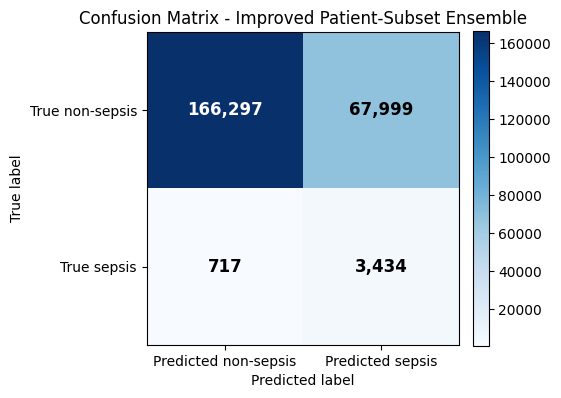

Saved: /kaggle/working/figure_confusion_matrix_improved_pse.png


In [17]:
cm = confusion_matrix(y_test, test_pred, labels=[0, 1])

fig, ax = plt.subplots(figsize=(5.5, 4.8))

im = ax.imshow(cm, cmap="Blues")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Predicted non-sepsis", "Predicted sepsis"])
ax.set_yticklabels(["True non-sepsis", "True sepsis"])

color_threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center",
            color="white" if cm[i, j] > color_threshold else "black",
            fontsize=12,
            fontweight="bold"
        )

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix - Improved Patient-Subset Ensemble")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()

fig_path = "/kaggle/working/figure_confusion_matrix_improved_pse.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

### Precision-Recall curve

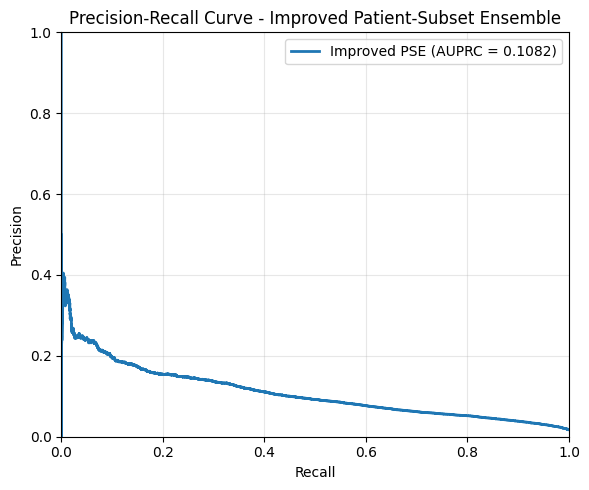

Saved: /kaggle/working/figure_pr_curve_improved_pse.png


In [18]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, ensemble_test_prob)
auprc = average_precision_score(y_test, ensemble_test_prob)

fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(
    recall,
    precision,
    linewidth=2,
    label=f"Improved PSE (AUPRC = {auprc:.4f})"
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve - Improved Patient-Subset Ensemble")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(loc="best")

plt.tight_layout()

fig_path = "/kaggle/working/figure_pr_curve_improved_pse.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

### ROC curve

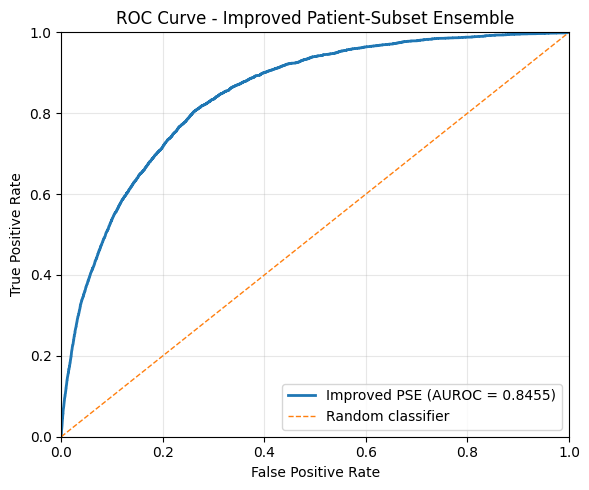

Saved: /kaggle/working/figure_roc_curve_improved_pse.png


In [19]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, ensemble_test_prob)
auroc = roc_auc_score(y_test, ensemble_test_prob)

fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Improved PSE (AUROC = {auroc:.4f})"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Random classifier"
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - Improved Patient-Subset Ensemble")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(loc="best")

plt.tight_layout()

fig_path = "/kaggle/working/figure_roc_curve_improved_pse.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

### Error analysis inputs for the main ensemble model

In [20]:
import numpy as np
import pandas as pd

# ===== Build sequence-level prediction tables =====
df_val_pred = pd.DataFrame({
    "row_id": np.arange(len(y_val)),
    "patient_id": id_val,
    "y_true": y_val.astype(int),
    "y_prob": ensemble_val_prob,
})

df_test_pred = pd.DataFrame({
    "row_id": np.arange(len(y_test)),
    "patient_id": id_test,
    "y_true": y_test.astype(int),
    "y_prob": ensemble_test_prob,
})

df_val_pred["y_pred"] = (df_val_pred["y_prob"] >= best_threshold).astype(int)
df_test_pred["y_pred"] = (df_test_pred["y_prob"] >= best_threshold).astype(int)

def error_type(y_true, y_pred):
    if y_true == 1 and y_pred == 1:
        return "TP"
    elif y_true == 1 and y_pred == 0:
        return "FN"
    elif y_true == 0 and y_pred == 1:
        return "FP"
    else:
        return "TN"

df_val_pred["error_type"] = [
    error_type(t, p) for t, p in zip(df_val_pred["y_true"], df_val_pred["y_pred"])
]
df_test_pred["error_type"] = [
    error_type(t, p) for t, p in zip(df_test_pred["y_true"], df_test_pred["y_pred"])
]

# ===== Ensemble disagreement / uncertainty =====
df_val_pred["member_prob_std"] = val_probs_array.std(axis=0)
df_val_pred["member_prob_min"] = val_probs_array.min(axis=0)
df_val_pred["member_prob_max"] = val_probs_array.max(axis=0)

df_test_pred["member_prob_std"] = test_probs_array.std(axis=0)
df_test_pred["member_prob_min"] = test_probs_array.min(axis=0)
df_test_pred["member_prob_max"] = test_probs_array.max(axis=0)

print("Validation error types:")
print(df_val_pred["error_type"].value_counts())

print("\nTest error types:")
print(df_test_pred["error_type"].value_counts())

df_val_pred.to_csv("ensemble_val_predictions.csv", index=False)
df_test_pred.to_csv("ensemble_test_predictions.csv", index=False)

print("\nSaved:")
print("- ensemble_val_predictions.csv")
print("- ensemble_test_predictions.csv")

Validation error types:
error_type
TN    130997
FP     56172
TP      2921
FN       707
Name: count, dtype: int64

Test error types:
error_type
TN    166297
FP     67999
TP      3434
FN       717
Name: count, dtype: int64

Saved:
- ensemble_val_predictions.csv
- ensemble_test_predictions.csv


In [21]:
def summarize_error_groups(df):
    return (
        df.groupby("error_type")
          .agg(
              n=("row_id", "size"),
              mean_prob=("y_prob", "mean"),
              median_prob=("y_prob", "median"),
              mean_member_std=("member_prob_std", "mean"),
              n_patients=("patient_id", "nunique"),
          )
          .sort_values("n", ascending=False)
    )

print("Validation summary:")
display(summarize_error_groups(df_val_pred))

print("\nTest summary:")
display(summarize_error_groups(df_test_pred))

Validation summary:


,n,mean_prob,median_prob,mean_member_std,n_patients
error_type,,,,,
TN,130997,0.140823,0.099051,0.068128,6135
FP,56172,0.668142,0.663352,0.102914,5113
TP,2921,0.764097,0.803543,0.070732,379
FN,707,0.222184,0.225677,0.098757,168



Test summary:


,n,mean_prob,median_prob,mean_member_std,n_patients
error_type,,,,,
TN,166297,0.140935,0.099143,0.068100,7715
FP,67999,0.668802,0.664672,0.102495,6410
TP,3434,0.770566,0.815424,0.070187,454
FN,717,0.242982,0.253456,0.104423,185


### Metadata

In [22]:
meta_train = pd.read_csv('/kaggle/input/datasets/thuhiuhong/traintestval-lstm/meta_test (1).csv')
meta_val = pd.read_csv('/kaggle/input/datasets/thuhiuhong/traintestval-lstm/meta_train (1).csv')
meta_test = pd.read_csv('/kaggle/input/datasets/thuhiuhong/traintestval-lstm/meta_val (1).csv')

# ===== Merge on row_id =====
df_val_analysis = df_val_pred.merge(
    meta_val,
    on='row_id',
    how='left',
    validate='one_to_one',
    suffixes=('_pred', '_meta')
)

df_test_analysis = df_test_pred.merge(
    meta_test,
    on='row_id',
    how='left',
    validate='one_to_one',
    suffixes=('_pred', '_meta')
)

# ===== Correct merge checks =====
assert len(df_val_analysis) == len(df_val_pred)
assert len(df_test_analysis) == len(df_test_pred)

assert (df_val_analysis['patient_id_pred'].values == df_val_analysis['patient_id_meta'].values).all()
assert (df_test_analysis['patient_id_pred'].values == df_test_analysis['patient_id_meta'].values).all()

assert (df_val_analysis['y_true_pred'].values == df_val_analysis['y_true_meta'].values).all()
assert (df_test_analysis['y_true_pred'].values == df_test_analysis['y_true_meta'].values).all()

# Only check metadata columns that should not be missing
assert df_val_analysis['window_end_hour'].isna().sum() == 0
assert df_test_analysis['window_end_hour'].isna().sum() == 0

assert df_val_analysis['raw_missing_rate_window'].isna().sum() == 0
assert df_test_analysis['raw_missing_rate_window'].isna().sum() == 0

# ===== Rename columns back to clean names =====
df_val_analysis = df_val_analysis.rename(columns={
    'patient_id_pred': 'patient_id',
    'y_true_pred': 'y_true'
}).drop(columns=['patient_id_meta', 'y_true_meta'])

df_test_analysis = df_test_analysis.rename(columns={
    'patient_id_pred': 'patient_id',
    'y_true_pred': 'y_true'
}).drop(columns=['patient_id_meta', 'y_true_meta'])

print("df_val_analysis:", df_val_analysis.shape)
print("df_test_analysis:", df_test_analysis.shape)

print("\nMissing check:")
print("VAL  - window_end_hour:", df_val_analysis['window_end_hour'].isna().sum())
print("VAL  - raw_missing_rate_window:", df_val_analysis['raw_missing_rate_window'].isna().sum())
print("VAL  - last_HR_raw:", df_val_analysis['last_HR_raw'].isna().sum())

print("TEST - window_end_hour:", df_test_analysis['window_end_hour'].isna().sum())
print("TEST - raw_missing_rate_window:", df_test_analysis['raw_missing_rate_window'].isna().sum())
print("TEST - last_HR_raw:", df_test_analysis['last_HR_raw'].isna().sum())

display(df_val_analysis.head())
display(df_test_analysis.head())

print("Merge check passed.")

AssertionError: 

In [ ]:
# ===== Fixed missingness cutoff from TRAIN =====
missing_cutoff = meta_train['raw_missing_rate_window'].median()
print("missing_cutoff from train =", missing_cutoff)

In [ ]:
# ===== Create clinically meaningful subgroups =====

for df in [df_val_analysis, df_test_analysis]:
    df['hr_high'] = (df['last_HR_raw'] >= 100).astype(int)
    df['resp_high'] = (df['last_Resp_raw'] >= 22).astype(int)
    df['sbp_low'] = (df['last_SBP_raw'] <= 100).astype(int)
    df['map_low'] = (df['last_MAP_raw'] < 65).astype(int)

    # Use the fixed cutoff from TRAIN
    df['missing_high'] = (df['raw_missing_rate_window'] >= missing_cutoff).astype(int)

    df['delta_hr_up'] = (df['delta_HR_raw'] > 0).astype(int)
    df['delta_resp_up'] = (df['delta_Resp_raw'] > 0).astype(int)
    df['delta_sbp_down'] = (df['delta_SBP_raw'] < 0).astype(int)
    df['delta_map_down'] = (df['delta_MAP_raw'] < 0).astype(int)

    df['eda_pattern_strong'] = (
        (df['delta_hr_up'] == 1) &
        (df['delta_resp_up'] == 1) &
        (
            (df['delta_sbp_down'] == 1) |
            (df['delta_map_down'] == 1)
        )
    ).astype(int)

print("Done creating subgroup flags.")
print("Using fixed missing_cutoff from train:", missing_cutoff)

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, average_precision_score

def subgroup_report(df, group_col):
    rows = []

    for group_value, sub in df.groupby(group_col):
        y_true = sub['y_true'].values
        y_prob = sub['y_prob'].values
        y_pred = sub['y_pred'].values

        if len(np.unique(y_true)) < 2:
            auprc = np.nan
        else:
            auprc = average_precision_score(y_true, y_prob)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        precision = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        rows.append({
            'group': group_value,
            'n': len(sub),
            'positive_rate': sub['y_true'].mean(),
            'AUPRC': auprc,
            'sensitivity': sensitivity,
            'specificity': specificity,
            'precision': precision,
            'f1': f1,
            'FP': fp,
            'FN': fn,
            'TP': tp,
            'TN': tn,
            'mean_prob': sub['y_prob'].mean(),
            'mean_member_std': sub['member_prob_std'].mean()
        })

    return pd.DataFrame(rows).sort_values('group')

In [ ]:
# ===== First subgroup analyses =====

report_pattern_val = subgroup_report(df_val_analysis, 'eda_pattern_strong')
report_pattern_test = subgroup_report(df_test_analysis, 'eda_pattern_strong')

report_missing_val = subgroup_report(df_val_analysis, 'missing_high')
report_missing_test = subgroup_report(df_test_analysis, 'missing_high')

report_hr_val = subgroup_report(df_val_analysis, 'hr_high')
report_hr_test = subgroup_report(df_test_analysis, 'hr_high')

print("Validation - EDA pattern strong")
display(report_pattern_val)

print("Test - EDA pattern strong")
display(report_pattern_test)

print("Validation - Missing high")
display(report_missing_val)

print("Test - Missing high")
display(report_missing_test)

print("Validation - HR high")
display(report_hr_val)

print("Test - HR high")
display(report_hr_test)

In [ ]:
print("Current validation error counts:")
print(df_val_analysis['error_type'].value_counts())

print("\nCurrent test error counts:")
print(df_test_analysis['error_type'].value_counts())

In [ ]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(
    df_test_analysis['y_true'],
    df_test_analysis['y_pred'],
    labels=[0, 1]
).ravel()

print("TN, FP, FN, TP =", tn, fp, fn, tp)

### FN and FP by subgroup.

In [ ]:
def fn_report(df, group_col):
    rows = []

    for group_value, sub in df.groupby(group_col):
        pos = sub[sub['y_true'] == 1].copy()   # Only evaluate true positive windows
        n_pos = len(pos)

        fn = (pos['error_type'] == 'FN').sum()
        tp = (pos['error_type'] == 'TP').sum()

        fn_rate = fn / n_pos if n_pos > 0 else np.nan
        tp_rate = tp / n_pos if n_pos > 0 else np.nan

        fn_sub = pos[pos['error_type'] == 'FN']

        rows.append({
            'group': group_value,
            'n_total': len(sub),
            'n_positive': n_pos,
            'FN': fn,
            'TP': tp,
            'FN_rate_within_positive': fn_rate,
            'TP_rate_within_positive': tp_rate,
            'mean_prob_positive': pos['y_prob'].mean() if n_pos > 0 else np.nan,
            'mean_prob_FN': fn_sub['y_prob'].mean() if len(fn_sub) > 0 else np.nan,
            'mean_member_std_FN': fn_sub['member_prob_std'].mean() if len(fn_sub) > 0 else np.nan,
        })

    return pd.DataFrame(rows).sort_values('group')

In [ ]:
def fp_report(df, group_col):
    rows = []

    for group_value, sub in df.groupby(group_col):
        neg = sub[sub['y_true'] == 0].copy()   # Only evaluate true negative windows
        n_neg = len(neg)

        fp = (neg['error_type'] == 'FP').sum()
        tn = (neg['error_type'] == 'TN').sum()

        fp_rate = fp / n_neg if n_neg > 0 else np.nan
        tn_rate = tn / n_neg if n_neg > 0 else np.nan

        fp_sub = neg[neg['error_type'] == 'FP']

        rows.append({
            'group': group_value,
            'n_total': len(sub),
            'n_negative': n_neg,
            'FP': fp,
            'TN': tn,
            'FP_rate_within_negative': fp_rate,
            'TN_rate_within_negative': tn_rate,
            'mean_prob_negative': neg['y_prob'].mean() if n_neg > 0 else np.nan,
            'mean_prob_FP': fp_sub['y_prob'].mean() if len(fp_sub) > 0 else np.nan,
            'mean_member_std_FP': fp_sub['member_prob_std'].mean() if len(fp_sub) > 0 else np.nan,
        })

    return pd.DataFrame(rows).sort_values('group')

In [ ]:
# ===== FN reports on test =====
fn_pattern_test = fn_report(df_test_analysis, 'eda_pattern_strong')
fn_missing_test = fn_report(df_test_analysis, 'missing_high')
fn_hr_test = fn_report(df_test_analysis, 'hr_high')
fn_resp_test = fn_report(df_test_analysis, 'resp_high')
fn_sbp_test = fn_report(df_test_analysis, 'sbp_low')
fn_map_test = fn_report(df_test_analysis, 'map_low')

print("Test - FN by EDA pattern strong")
display(fn_pattern_test)

print("Test - FN by Missing high")
display(fn_missing_test)

print("Test - FN by HR high")
display(fn_hr_test)

print("Test - FN by Resp high")
display(fn_resp_test)

print("Test - FN by SBP low")
display(fn_sbp_test)

print("Test - FN by MAP low")
display(fn_map_test)

In [ ]:
# ===== FP reports on test =====
fp_pattern_test = fp_report(df_test_analysis, 'eda_pattern_strong')
fp_missing_test = fp_report(df_test_analysis, 'missing_high')
fp_hr_test = fp_report(df_test_analysis, 'hr_high')
fp_resp_test = fp_report(df_test_analysis, 'resp_high')
fp_sbp_test = fp_report(df_test_analysis, 'sbp_low')
fp_map_test = fp_report(df_test_analysis, 'map_low')

print("Test - FP by EDA pattern strong")
display(fp_pattern_test)

print("Test - FP by Missing high")
display(fp_missing_test)

print("Test - FP by HR high")
display(fp_hr_test)

print("Test - FP by Resp high")
display(fp_resp_test)

print("Test - FP by SBP low")
display(fp_sbp_test)

print("Test - FP by MAP low")
display(fp_map_test)

## Case studies of the main model at the window level

In [ ]:
# ===== Select a representative TP window near onset =====

tp_candidates = df_test_analysis[
    (df_test_analysis['error_type'] == 'TP') &
    (df_test_analysis['is_sepsis_patient'] == 1) &
    (df_test_analysis['hours_to_onset'] >= 0) &
    (df_test_analysis['hours_to_onset'] <= 6) &
    (
        (df_test_analysis['hr_high'] == 1) |
        (df_test_analysis['resp_high'] == 1) |
        (df_test_analysis['sbp_low'] == 1) |
        (df_test_analysis['map_low'] == 1)
    )
].copy()

tp_candidates = tp_candidates.sort_values(
    ['y_prob', 'member_prob_std'],
    ascending=[False, True]
)

print("Number of TP candidates:", len(tp_candidates))

tp_case = tp_candidates.iloc[0]

display(pd.DataFrame([tp_case])[[
    'patient_id', 'row_id', 'error_type', 'y_true', 'y_pred', 'y_prob',
    'member_prob_std', 'window_start_hour', 'window_end_hour',
    'onset_hour', 'hours_to_onset', 'raw_missing_rate_window',
    'last_HR_raw', 'last_Resp_raw', 'last_SBP_raw', 'last_MAP_raw',
    'hr_high', 'resp_high', 'sbp_low', 'map_low', 'missing_high',
    'eda_pattern_strong'
]])

In [ ]:
# ===== Select a representative FN window near onset =====

fn_candidates = df_test_analysis[
    (df_test_analysis['error_type'] == 'FN') &
    (df_test_analysis['is_sepsis_patient'] == 1) &
    (df_test_analysis['hours_to_onset'] >= 0) &
    (df_test_analysis['hours_to_onset'] <= 6)
].copy()

# Prioritize missingness-related failure modes, followed by strong EDA patterns
fn_candidates = fn_candidates.sort_values(
    ['missing_high', 'eda_pattern_strong', 'y_prob', 'member_prob_std'],
    ascending=[False, False, False, True]
)

print("Number of FN candidates:", len(fn_candidates))

fn_case = fn_candidates.iloc[0]

display(pd.DataFrame([fn_case])[[
    'patient_id', 'row_id', 'error_type', 'y_true', 'y_pred', 'y_prob',
    'member_prob_std', 'window_start_hour', 'window_end_hour',
    'onset_hour', 'hours_to_onset', 'raw_missing_rate_window',
    'last_HR_raw', 'last_Resp_raw', 'last_SBP_raw', 'last_MAP_raw',
    'hr_high', 'resp_high', 'sbp_low', 'map_low', 'missing_high',
    'eda_pattern_strong'
]])

In [ ]:
# ===== Select a representative FP window on a non-sepsis patient =====

fp_candidates = df_test_analysis[
    (df_test_analysis['error_type'] == 'FP') &
    (df_test_analysis['is_sepsis_patient'] == 0) &
    (
        (df_test_analysis['hr_high'] == 1) |
        (df_test_analysis['resp_high'] == 1) |
        (df_test_analysis['sbp_low'] == 1) |
        (df_test_analysis['map_low'] == 1)
    )
].copy()

fp_candidates = fp_candidates.sort_values(
    ['y_prob', 'member_prob_std'],
    ascending=[False, True]
)

print("Number of FP candidates:", len(fp_candidates))

fp_case = fp_candidates.iloc[0]

display(pd.DataFrame([fp_case])[[
    'patient_id', 'row_id', 'error_type', 'y_true', 'y_pred', 'y_prob',
    'member_prob_std', 'window_start_hour', 'window_end_hour',
    'onset_hour', 'hours_to_onset', 'raw_missing_rate_window',
    'last_HR_raw', 'last_Resp_raw', 'last_SBP_raw', 'last_MAP_raw',
    'hr_high', 'resp_high', 'sbp_low', 'map_low', 'missing_high',
    'eda_pattern_strong'
]])

In [ ]:
# ===== Summary of the refined case-study set =====

selected_cases = pd.DataFrame([
    tp_case,
    fn_case,
    fp_case
]).copy()

selected_cases.index = ['TP_case', 'FN_case', 'FP_case']

display(selected_cases[[
    'patient_id', 'row_id', 'error_type', 'y_true', 'y_pred', 'y_prob',
    'member_prob_std', 'window_start_hour', 'window_end_hour',
    'onset_hour', 'hours_to_onset', 'raw_missing_rate_window',
    'last_HR_raw', 'last_Resp_raw', 'last_SBP_raw', 'last_MAP_raw',
    'hr_high', 'resp_high', 'sbp_low', 'map_low', 'missing_high',
    'eda_pattern_strong'
]])

In [ ]:
# Plot prediction trajectories for the selected case-study patients
DECISION_THRESHOLD = best_threshold

for case_name, case_row in selected_cases.iterrows():
    patient_id = case_row["patient_id"]

    patient_df = (
        df_test_analysis[df_test_analysis["patient_id"] == patient_id]
        .sort_values("window_end_hour")
        .copy()
    )

    fig, ax = plt.subplots(figsize=(8, 4.8))

    ax.plot(
        patient_df["window_end_hour"],
        patient_df["y_prob"],
        marker="o",
        linewidth=1.8,
        label="Predicted probability",
    )

    # Decision threshold
    ax.axhline(
        DECISION_THRESHOLD,
        linestyle=":",
        linewidth=1.5,
        color="red",
        label=f"Decision threshold = {DECISION_THRESHOLD:.2f}",
    )

    # Sepsis onset line for sepsis patients
    if pd.notna(case_row["onset_hour"]):
        ax.axvline(
            case_row["onset_hour"],
            linestyle="--",
            linewidth=1.5,
            color="tab:blue",
            label="Sepsis onset hour",
        )

    # Highlight selected case-study window
    ax.scatter(
        [case_row["window_end_hour"]],
        [case_row["y_prob"]],
        s=120,
        color="darkorange",
        edgecolor="black",
        zorder=5,
        label=f"Selected {case_row['error_type']} window",
    )

    # Annotate selected window
    ax.annotate(
        (
            f"{case_row['error_type']} window\n"
            f"hour={case_row['window_end_hour']:.0f}\n"
            f"prob={case_row['y_prob']:.3f}"
        ),
        xy=(case_row["window_end_hour"], case_row["y_prob"]),
        xytext=(10, 10),
        textcoords="offset points",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85),
        arrowprops=dict(arrowstyle="->", lw=1),
    )

    ax.set_xlabel("Window end hour")
    ax.set_ylabel("Predicted sepsis probability")
    ax.set_title(f"Prediction Trajectory - {case_name} | patient_id={patient_id}")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), loc="best")

    plt.tight_layout()
    plt.show()

### Subgroup performance

In [ ]:
from sklearn.metrics import average_precision_score

def compute_metrics(df):
    y_true = df['y_true']
    y_pred = df['y_pred']
    y_prob = df['y_prob']
    
    tp = ((y_true == 1) & (y_pred == 1)).sum()
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    tn = ((y_true == 0) & (y_pred == 0)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    
    try:
        auprc = average_precision_score(y_true, y_prob)
    except:
        auprc = np.nan
    
    return pd.Series({
        'n': len(df),
        'positive_rate': y_true.mean(),
        'sensitivity': sensitivity,
        'specificity': specificity,
        'AUPRC': auprc,
        'mean_pred_prob': y_prob.mean()
    })


subgroups = [
    'hr_high',
    'resp_high',
    'sbp_low',
    'map_low',
    'missing_high',
    'eda_pattern_strong'
]

rows = []

for sg in subgroups:
    for val in [0, 1]:
        df_sub = df_test_analysis[df_test_analysis[sg] == val]
        
        metrics = compute_metrics(df_sub)
        metrics['subgroup'] = sg
        metrics['value'] = val
        
        rows.append(metrics)

df_subgroup_table = pd.DataFrame(rows)

df_subgroup_table = df_subgroup_table[
    ['subgroup', 'value', 'n', 'positive_rate', 'sensitivity', 'specificity', 'AUPRC', 'mean_pred_prob']
].sort_values(['subgroup', 'value'])

display(df_subgroup_table)

In [ ]:
df_subgroup_table.to_csv('/kaggle/working/subgroup_performance_table.csv', index=False)

### FN/FP by missingness

In [ ]:
rows = []

for val in [0, 1]:
    df_sub = df_test_analysis[df_test_analysis['missing_high'] == val]
    
    # positive group
    df_pos = df_sub[df_sub['y_true'] == 1]
    fn_rate = ((df_pos['y_pred'] == 0).sum() / len(df_pos)) if len(df_pos) > 0 else np.nan
    
    # negative group
    df_neg = df_sub[df_sub['y_true'] == 0]
    fp_rate = ((df_neg['y_pred'] == 1).sum() / len(df_neg)) if len(df_neg) > 0 else np.nan
    
    mean_prob = df_sub['y_prob'].mean()
    
    rows.append({
        'missing_high': val,
        'n': len(df_sub),
        'FN_rate_within_positive': fn_rate,
        'FP_rate_within_negative': fp_rate,
        'mean_pred_prob': mean_prob
    })

df_missing_table = pd.DataFrame(rows)

display(df_missing_table)

In [ ]:
df_missing_table.to_csv('/kaggle/working/missingness_error_table.csv', index=False)